# Modelagem e simulação

Roberto M. Cesar Jr. - IME - USP

rmcesar@usp.br

# Versão original estática

Velocidade média entre t = 1s e t = 3s: 3.50 m/s


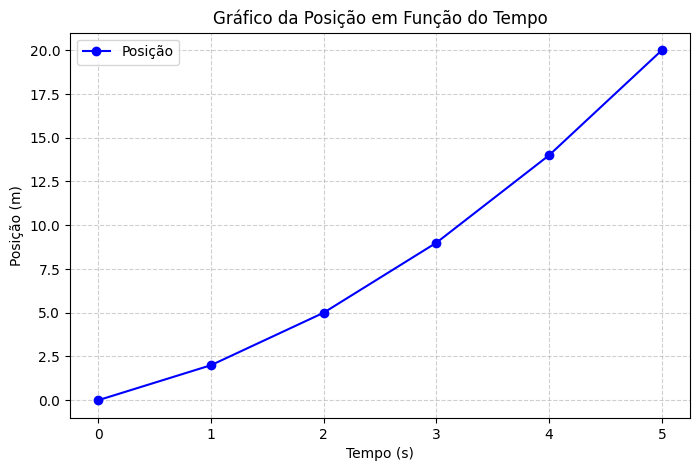

In [ ]:
import matplotlib.pyplot as plt

# Dados do exemplo
tempo = [0, 1, 2, 3, 4, 5]  # em segundos
posicao = [0, 2, 5, 9, 14, 20]  # em metros

# Cálculo da velocidade média em um intervalo específico
def velocidade_media(t1, t2, x1, x2):
    return (x2 - x1) / (t2 - t1)

# Exemplo de cálculo: entre t = 1 s e t = 3 s
t_inicial, t_final = 1, 3
x_inicial, x_final = posicao[t_inicial], posicao[t_final]
v_media = velocidade_media(t_inicial, t_final, x_inicial, x_final)

print(f"Velocidade média entre t = {t_inicial}s e t = {t_final}s: {v_media:.2f} m/s")

# Plotando o gráfico posição x tempo
plt.figure(figsize=(8, 5))
plt.plot(tempo, posicao, marker='o', color='blue', label='Posição')
plt.title("Gráfico da Posição em Função do Tempo")
plt.xlabel("Tempo (s)")
plt.ylabel("Posição (m)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


# Versão com animação

Esta versão pode não funcionar no Jupyter Notebook. Salve um arquivo em disco e rode com o python diretamente. Veja uma [animação aqui.](https://youtu.be/D3J3lDQJZls)

Velocidade media entre t = 1s e t = 3s: 3.50 m/s
V√≠deo salvo em: animacao_posicao_tempo.mp4


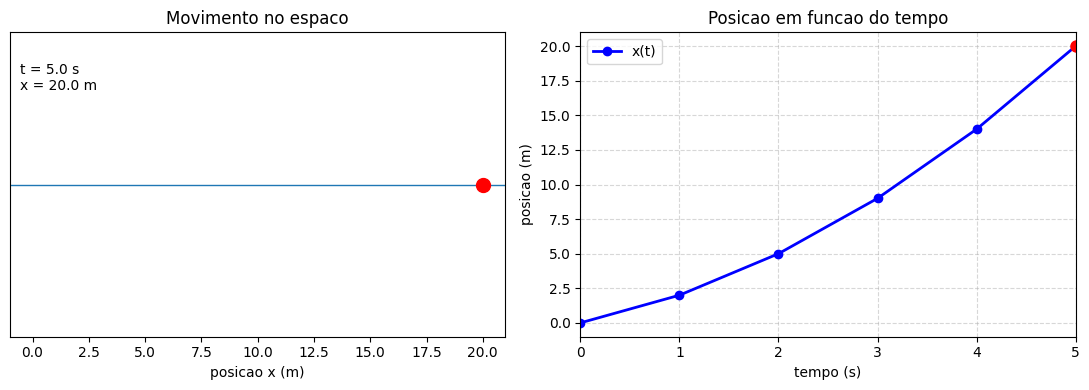

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


# -----------------------------------------
# Dados
# -----------------------------------------
def load_data():
    tempo = np.array([0, 1, 2, 3, 4, 5], dtype=float)
    posicao = np.array([0, 2, 5, 9, 14, 20], dtype=float)
    return tempo, posicao


# -----------------------------------------
# Velocidade m√©dia
# -----------------------------------------
def velocidade_media(t1, t2, x1, x2):
    return (x2 - x1) / (t2 - t1)


# -----------------------------------------
# Cria√ß√£o da figura
# -----------------------------------------
def create_figure(tempo, posicao):
    fig, (ax_pos, ax_xt) = plt.subplots(1, 2, figsize=(11, 4))

    # Painel 1: movimento no espa√ßo
    ax_pos.set_title("Movimento no espaco")
    ax_pos.set_xlim(posicao.min() - 1, posicao.max() + 1)
    ax_pos.set_ylim(-1, 1)
    ax_pos.set_yticks([])
    ax_pos.set_xlabel("posicao x (m)")
    ax_pos.axhline(0, linewidth=1)

    particle, = ax_pos.plot([], [], "ro", markersize=10)

    # Painel 2: gr√°fico x(t)
    ax_xt.set_title("Posicao em funcao do tempo")
    ax_xt.set_xlim(tempo.min(), tempo.max())
    ax_xt.set_ylim(posicao.min() - 1, posicao.max() + 1)
    ax_xt.set_xlabel("tempo (s)")
    ax_xt.set_ylabel("posicao (m)")
    ax_xt.grid(True, linestyle="--", alpha=0.5)

    line_xt, = ax_xt.plot([], [], "bo-", linewidth=2, label="x(t)")
    point_xt, = ax_xt.plot([], [], "ro", markersize=8)

    hud = ax_pos.text(
        0.02, 0.90, "",
        transform=ax_pos.transAxes,
        ha="left",
        va="top"
    )

    ax_xt.legend()

    return fig, particle, line_xt, point_xt, hud


# -----------------------------------------
# Inicializa
# -----------------------------------------
def init_animation(particle, line_xt, point_xt, hud):
    particle.set_data([], [])
    line_xt.set_data([], [])
    point_xt.set_data([], [])
    hud.set_text("")
    return particle, line_xt, point_xt, hud


# -----------------------------------------
# Atualizacao da animacao
# -----------------------------------------
def update(frame, tempo, posicao, particle, line_xt, point_xt, hud):
    particle.set_data([posicao[frame]], [0])

    # Curva x(t) parcial
    line_xt.set_data(tempo[:frame + 1], posicao[:frame + 1])

    # Ponto atual no grafico x(t)
    point_xt.set_data([tempo[frame]], [posicao[frame]])

    # HUD
    hud.set_text(
        f"t = {tempo[frame]:.1f} s\n"
        f"x = {posicao[frame]:.1f} m"
    )

    return particle, line_xt, point_xt, hud


# -----------------------------------------
# Geracao da animacao
# -----------------------------------------
def create_animation(tempo, posicao, interval=800):
    fig, particle, line_xt, point_xt, hud = create_figure(tempo, posicao)

    ani = FuncAnimation(
        fig,
        update,
        frames=len(tempo),
        init_func=lambda: init_animation(particle, line_xt, point_xt, hud),
        fargs=(tempo, posicao, particle, line_xt, point_xt, hud),
        interval=interval,
        blit=True,
        repeat=False
    )

    return fig, ani


# -----------------------------------------
# Main
# -----------------------------------------
def main():
    tempo, posicao = load_data()

    # Exemplo: velocidade media entre t=1 e t=3
    t_inicial, t_final = 1, 3
    x_inicial, x_final = posicao[t_inicial], posicao[t_final]
    v_media = velocidade_media(t_inicial, t_final, x_inicial, x_final)

    print(
        f"Velocidade media entre t = {t_inicial}s e t = {t_final}s: "
        f"{v_media:.2f} m/s"
    )

    fig, ani = create_animation(tempo, posicao, interval=800)

    # Salvar em MP4
    output_file = "animacao_posicao_tempo.mp4"
    ani.save(output_file, writer="ffmpeg", fps=1.25)

    print(f"V√≠deo salvo em: {output_file}")

    plt.tight_layout()
    plt.show()


# -----------------------------------------
# -----------------------------------------
if __name__ == "__main__":
    main()
